In [1]:
!pip install yfinance

In [2]:
# import repository (packages/libraries/modules)
import pandas as pd # we rename pandas for convenience as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf # import this function from this submodule
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import gaussian_kde, norm, iqr, skew, kurtosis, jarque_bera, kstest, anderson
from statsmodels.stats.diagnostic import lilliefors
import scipy.signal as ss
import pylab
import seaborn as sns

# CAC40 Daily Adjusted Closing Prices (1994-2024)

[*********************100%***********************]  1 of 1 completed


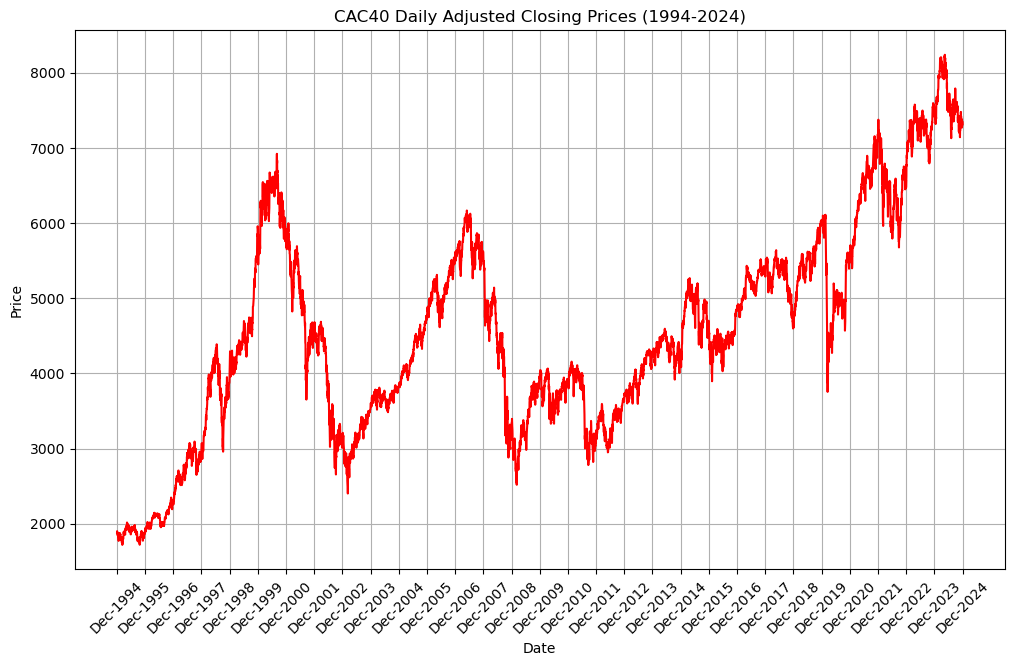

In [3]:
# Download CAC40 stock data for the specified period
CAC40 = yf.download("^FCHI", start="1994-12-31", end="2024-12-31",auto_adjust=True)


# Extract adjusted closing prices
adj_close_prices = CAC40['Close']

# Create a line chart
plt.figure(figsize=(12, 7))
plt.plot(adj_close_prices.index, adj_close_prices, color='red')

# Customizing x-axis labels for December 31 of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
# Add label and rotate them
plt.xticks(date_labels, formatted_labels, rotation=45)

plt.title('CAC40 Daily Adjusted Closing Prices (1994-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)

# Save the plot in png format Ilan
plt.savefig('CAC40_end1994_end_2024_daily.png', format='png', bbox_inches='tight')

plt.show()

In [4]:
from tabulate import tabulate

# Count trading days, months, and years
num_days = len(CAC40)
num_months = CAC40.index.to_period('M').nunique()
num_years = CAC40.index.to_period('Y').nunique()

# Create a summary DataFrame
summary_table = pd.DataFrame({
    'Metric': ['Number of Trading Days', 'Number of Months', 'Number of Years'],
    'Value': [num_days, num_months, num_years]
})

# ---- Display nicely in the console ----
print("\nCAC40 Data Summary (1994–2024)\n")
print(tabulate(summary_table, headers='keys', tablefmt='fancy_grid', showindex=False))

# Save as CSV
summary_table.to_csv('CAC40_data_summary.csv', index=False)


CAC40 Data Summary (1994–2024)

╒════════════════════════╤═════════╕
│ Metric                 │   Value │
╞════════════════════════╪═════════╡
│ Number of Trading Days │    7639 │
├────────────────────────┼─────────┤
│ Number of Months       │     360 │
├────────────────────────┼─────────┤
│ Number of Years        │      30 │
╘════════════════════════╧═════════╛


# CAC 40 Monthly Adjusted Closing Prices (1994-2024)

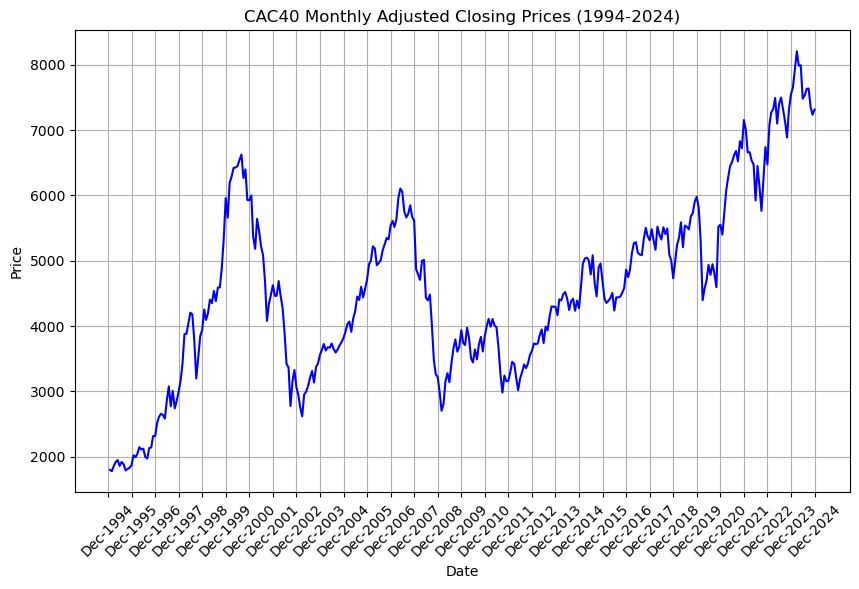

In [5]:
# Resample data to monthly frequency
monthly_data = CAC40['Close'].resample('ME').last()

# Create a line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_data.index, monthly_data, color='blue')

# Customizing x-axis labels for December of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
# Add label and rotate them
plt.xticks(date_labels, formatted_labels, rotation=45)

plt.title('CAC40 Monthly Adjusted Closing Prices (1994-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)

# Save the plot in png format
plt.savefig('CAC40_end_1994_end_2024_monthly.png', format='png', bbox_inches='tight')

plt.show()


# CAC 40 Annual Adjusted Closing Prices (1994-2024)

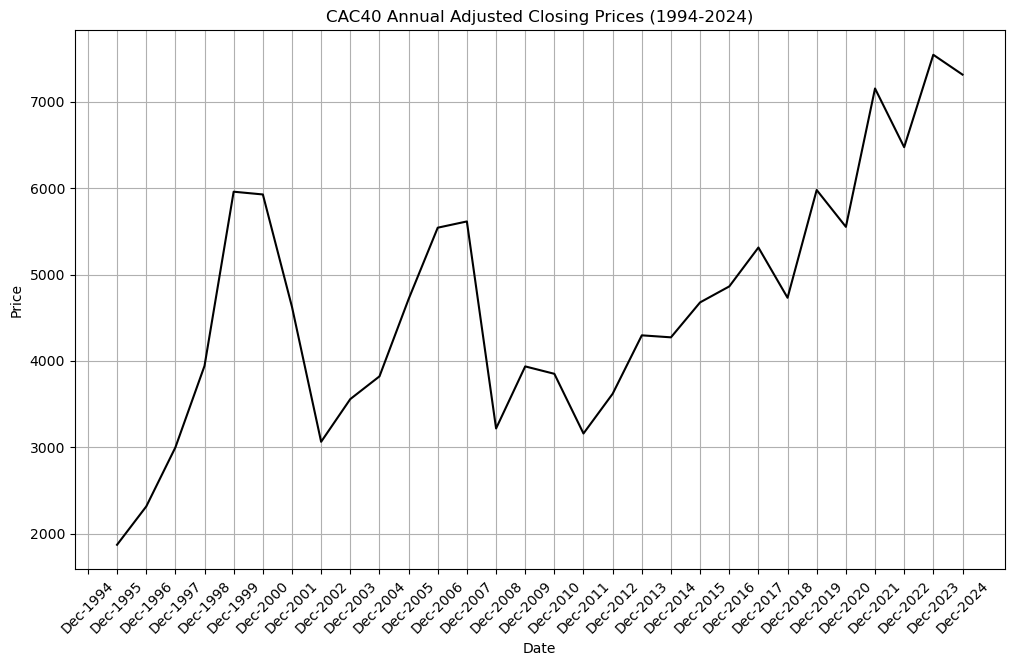

In [6]:
# Resample data to annual frequency
annual_data = CAC40['Close'].resample('YE').last()

# Create a line chart
plt.figure(figsize=(12, 7))
plt.plot(annual_data.index, annual_data, color='black')

# Customizing x-axis labels for December of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
# Add label and rotate them
plt.xticks(date_labels, formatted_labels, rotation=45)

plt.title('CAC40 Annual Adjusted Closing Prices (1994-2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)

# Save the plot in png format
plt.savefig('CAC40_prices_end_1994_end_2018_annual.png', format='png', bbox_inches='tight')

plt.show()

# LOG RETURNS

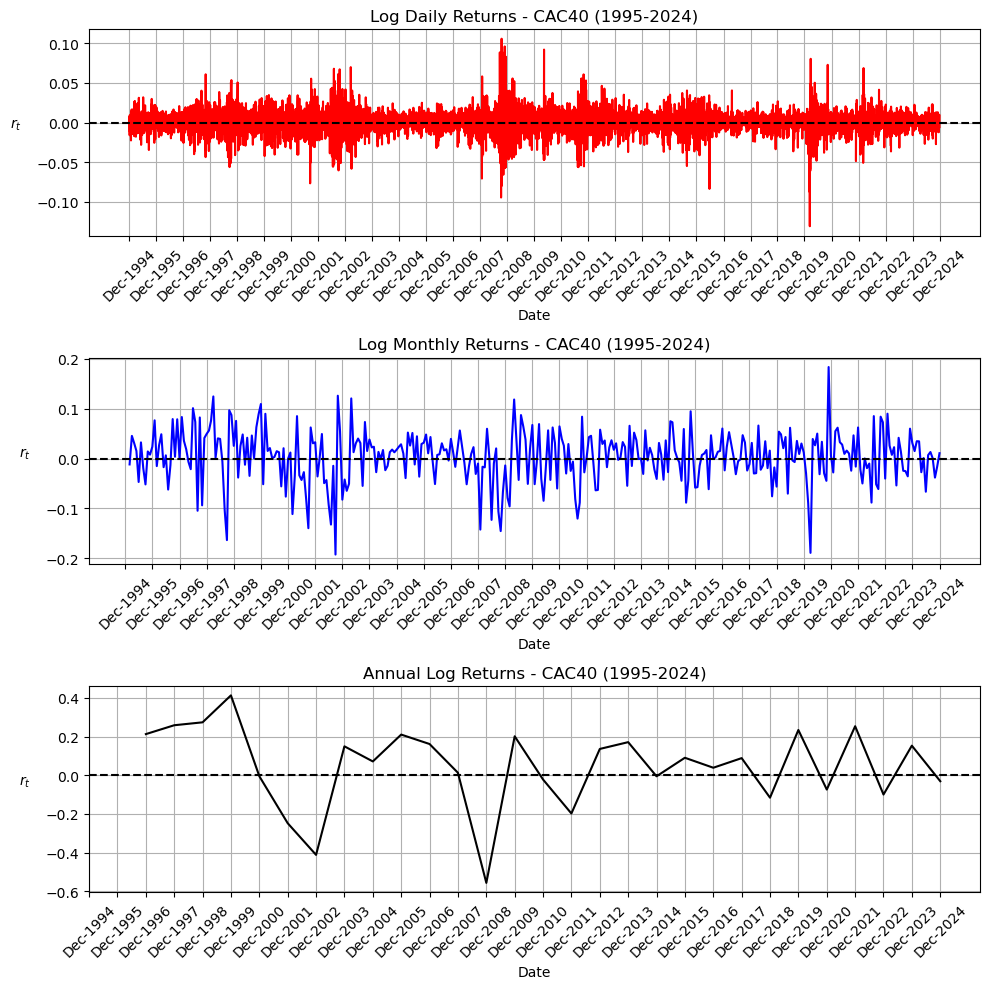

In [7]:
# Extract daily log returns
log_price_daily = np.log(CAC40['Close'])
log_returns_daily = log_price_daily.diff().dropna().squeeze()

#Calculate Monthly Return
log_price_monthly = np.log(CAC40['Close']).resample('ME').last().squeeze()
log_returns_monthly = log_price_monthly.diff().dropna()

# Calculate annual log returns (remove the first obs which is a NaN)
log_price_annual = np.log(CAC40['Close']).resample('YE').last().squeeze()
log_returns_annual = log_price_annual.diff().dropna()

#annual_data = CAC40['Close'].resample('Y').last()
#log_returns_annual = np.log(annual_data / annual_data.shift(1)).dropna()

# Creating three plots
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Plot of daily log returns
axs[0].plot(log_returns_daily.index, log_returns_daily, color='red')
axs[0].axhline(y=0, color='black', linestyle='--')
axs[0].set_title('Log Daily Returns - CAC40 (1995-2024)')
axs[0].set_xlabel('Date')
axs[0].set_ylabel(r'$r_t$', rotation=0, labelpad=15)
axs[0].grid(True)

# Add "Dec-Year" at the end of each year (first plot)
date_labels = pd.date_range(start="1994-12-31", end="2024-12-31", freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
axs[0].set_xticks(date_labels)
axs[0].set_xticklabels(formatted_labels, rotation=45)

#Plot of monthly log returns
axs[1].plot(log_returns_monthly.index, log_returns_monthly, color='blue')
axs[1].axhline(y=0, color='black', linestyle='--')
axs[1].set_title('Log Monthly Returns - CAC40 (1995-2024)')
axs[1].set_xlabel('Date')
axs[1].set_ylabel(r'$r_t$', rotation=0, labelpad=15)
axs[1].grid(True)

# Add "Dec-Year" at the end of each year (second plot)
axs[1].set_xticks(date_labels)
axs[1].set_xticklabels(formatted_labels, rotation=45)

# Plot of annual log returns
axs[2].plot(log_returns_annual.index, log_returns_annual, color='black')
axs[2].axhline(y=0, color='black', linestyle='--')
axs[2].set_title('Annual Log Returns - CAC40 (1995-2024)')
axs[2].set_xlabel('Date')
axs[2].set_ylabel(r'$r_t$', rotation=0, labelpad=15)
axs[2].grid(True)

# Add "Dec-Year" at the end of each year (third plot)
axs[2].set_xticks(date_labels)
axs[2].set_xticklabels(formatted_labels, rotation=45)


# Adjust spacing between plots
plt.tight_layout()

# Save the plot in png format
plt.savefig('CAC40_end_1994_end2024_logret.png', format='png', bbox_inches='tight')

plt.show()

# Statistics

In [8]:
# X contains returns at different frequencies

# Assurez-vous que log_returns_daily, log_returns_monthly, et log_returns_annual
# sont bien des Series pandas à une seule dimension.
# Si ce sont des DataFrames avec une seule colonne, vous pouvez les convertir comme ceci :
if isinstance(log_returns_daily, pd.DataFrame):
    log_returns_daily = log_returns_daily.iloc[:, 0]
if isinstance(log_returns_monthly, pd.DataFrame):
    log_returns_monthly = log_returns_monthly.iloc[:, 0]
if isinstance(log_returns_annual, pd.DataFrame):
    log_returns_annual = log_returns_annual.iloc[:, 0]
    
X = {
    'daily': log_returns_daily,
    'monthly': log_returns_monthly,
    'annual': log_returns_annual
}
display(X)

{'daily': Date
 1995-01-04    0.008396
 1995-01-05   -0.016061
 1995-01-06    0.007930
 1995-01-09   -0.011838
 1995-01-10   -0.002686
                 ...   
 2024-12-20   -0.002731
 2024-12-23   -0.000297
 2024-12-24    0.001425
 2024-12-27    0.009930
 2024-12-30   -0.005701
 Name: ^FCHI, Length: 7638, dtype: float64,
 'monthly': Date
 1995-02-28   -0.011749
 1995-03-31    0.045437
 1995-04-30    0.031236
 1995-05-31    0.015260
 1995-06-30   -0.046872
                 ...   
 2024-08-31    0.013119
 2024-09-30    0.000629
 2024-10-31   -0.038090
 2024-11-30   -0.015805
 2024-12-31    0.010785
 Freq: ME, Name: ^FCHI, Length: 359, dtype: float64,
 'annual': Date
 1996-12-31    0.212705
 1997-12-31    0.258534
 1998-12-31    0.273610
 1999-12-31    0.412933
 2000-12-31   -0.005368
 2001-12-31   -0.248035
 2002-12-31   -0.411694
 2003-12-31    0.149479
 2004-12-31    0.071384
 2005-12-31    0.210244
 2006-12-31    0.161514
 2007-12-31    0.012966
 2008-12-31   -0.556527
 2009-12-31    

In [9]:
def multi_fun(x):
    stat_tab = {
        'Mean': round(np.mean(x) * 100,5),
        'St.Deviation': round(np.std(x) * 100,5),
        'Diameter.C.I.Mean': round(1.96 * np.sqrt(np.var(x) / len(x)) * 100,5),
        'Skewness': round(skew(x),5),
        'Kurtosis': round(kurtosis(x, fisher = False),5),
        'Excess.Kurtosis': round(kurtosis(x, fisher = False) - 3,5),
        'Min': round(np.min(x) * 100,5),
        'Quant5': round(np.quantile(x, 0.05) * 100,5),
        'Quant25': round(np.quantile(x, 0.25) * 100,5),
        'Median': round(np.quantile(x, 0.50) * 100,5),
        'Quant75': round(np.quantile(x, 0.75) * 100,5),
        'Quant95': round(np.quantile(x, 0.95) * 100,5),
        'Max': round(np.max(x) * 100,5),
        'Jarque.Bera.stat': round(jarque_bera(x)[0],5),
        'Jarque.Bera.pvalue.X100': round(jarque_bera(x)[1] *100,5),
        'Lillie.test.stat': round(lilliefors(x)[0],5),
        'Lillie.test.pvalue.X100': round(lilliefors(x)[1] * 100,5),
        'N.obs': len(x)
    }
    return stat_tab 

In [10]:
print("daily:",lilliefors(log_returns_daily))
print("monthly:",lilliefors(log_returns_monthly))
print("ann:",lilliefors(log_returns_annual))

daily: (np.float64(0.06886021278185187), np.float64(0.0009999999999998899))
monthly: (np.float64(0.05809618592817789), np.float64(0.00794433861282428))
ann: (np.float64(0.11478571225278081), np.float64(0.42437253254319385))


In [11]:
# 1. 
statistics_dict = {}

# 2.
statistics_dict = {
    key: multi_fun(data.iloc[0:]) 
    for key, data in X.items()
}
# apply multi_fun to each returns ("series" in pandas) 
# which is located in one of the four key of our dictionary X   
# 3.
statistics_df = pd.DataFrame(statistics_dict)



# --- Build the statistics dataframe ---
statistics_dict = {key: multi_fun(data) for key, data in X.items()}
statistics_df = pd.DataFrame(statistics_dict)

# --- Reorder rows to group statistics nicely ---
row_order = [
    'Mean','St.Deviation','Diameter.C.I.Mean',
    'Skewness','Kurtosis','Excess.Kurtosis','Min',
    'Quant5','Quant25','Median','Quant75','Quant95','Max',
    'Jarque.Bera.stat','Jarque.Bera.pvalue.X100',
    'Lillie.test.stat','Lillie.test.pvalue.X100','N.obs'
]
statistics_df = statistics_df.reindex(row_order)

# --- Optional: rename columns and rows for clarity ---
statistics_df.columns = ['Daily', 'Monthly', 'Annual']
statistics_df.index = [
    'Mean (%)', 'Std. Deviation (%)', 'Diameter C.I. Mean (%)',
    'Skewness', 'Kurtosis', 'Excess Kurtosis', 'Minimum (%)',
    '5% Quantile (%)', '25% Quantile (%)', 'Median (%)',
    '75% Quantile (%)', '95% Quantile (%)', 'Maximum (%)',
    'Jarque–Bera Stat', 'Jarque–Bera p-value (×100)',
    'Lilliefors Stat', 'Lilliefors p-value (×100)', 'N. obs'
]

# --- Add section borders like in the PDF (thick lines between groups) ---
break_lines = {'Skewness', 'Jarque–Bera Stat'}

def add_section_borders(s):
    if s.name in break_lines:
        return ['border-top: 2px solid black'] * len(s)
    else:
        return [''] * len(s)

# --- Style and display the table ---
styled = (
    statistics_df.style
        .format("{:.4f}")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"), ("border", "1px solid black")]},
            {"selector": "thead th", "props": [("border-bottom", "2px solid black"), ("padding", "6px 10px"), ("font-weight", "bold")]},
            {"selector": "tbody th", "props": [("padding", "6px 10px"), ("font-weight", "bold")]},
            {"selector": "tbody td", "props": [("padding", "6px 16px")]},
        ])
        .apply(add_section_borders, axis=1)
        .set_caption("Table 1 – Descriptive Statistics of CAC 40 Log-Returns (Daily, Monthly, Annual)")
)

display(styled)

,Daily,Monthly,Annual
Mean (%),0.0177,0.3908,4.6990
Std. Deviation (%),1.3682,5.2350,20.7603
Diameter C.I. Mean (%),0.0307,0.5415,7.5560
Skewness,-0.2026,-0.5102,-1.0115
Kurtosis,9.0593,4.1513,4.0454
Excess Kurtosis,6.0593,1.1514,1.0454
Minimum (%),-13.0983,-19.2254,-55.6527
5% Quantile (%),-2.1549,-8.8186,-34.6230
25% Quantile (%),-0.6407,-2.7118,-3.0914
Median (%),0.0558,0.9961,8.8560


# Stylized Fact 2 : Returns are Stationnary

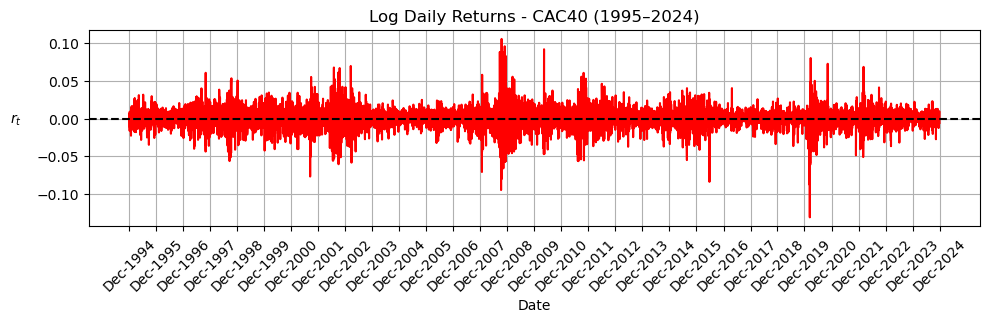

In [12]:
# Création du graphique
plt.figure(figsize=(10, 10/3))
plt.plot(log_returns_daily.index, log_returns_daily, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Log Daily Returns - CAC40 (1995–2024)')
plt.xlabel('Date')
plt.ylabel(r'$r_t$', rotation=0, labelpad=15)
plt.grid(True)

# Ajouter des labels "Dec-Year" à la fin de chaque année
date_labels = pd.date_range(start="1994-12-31", end="2024-12-31", freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
plt.xticks(date_labels, formatted_labels, rotation=45)

# Sauvegarder le graphique
plt.tight_layout()
plt.savefig('CAC40_daily_logreturns.png', format='png', bbox_inches='tight')

# Afficher
plt.show()

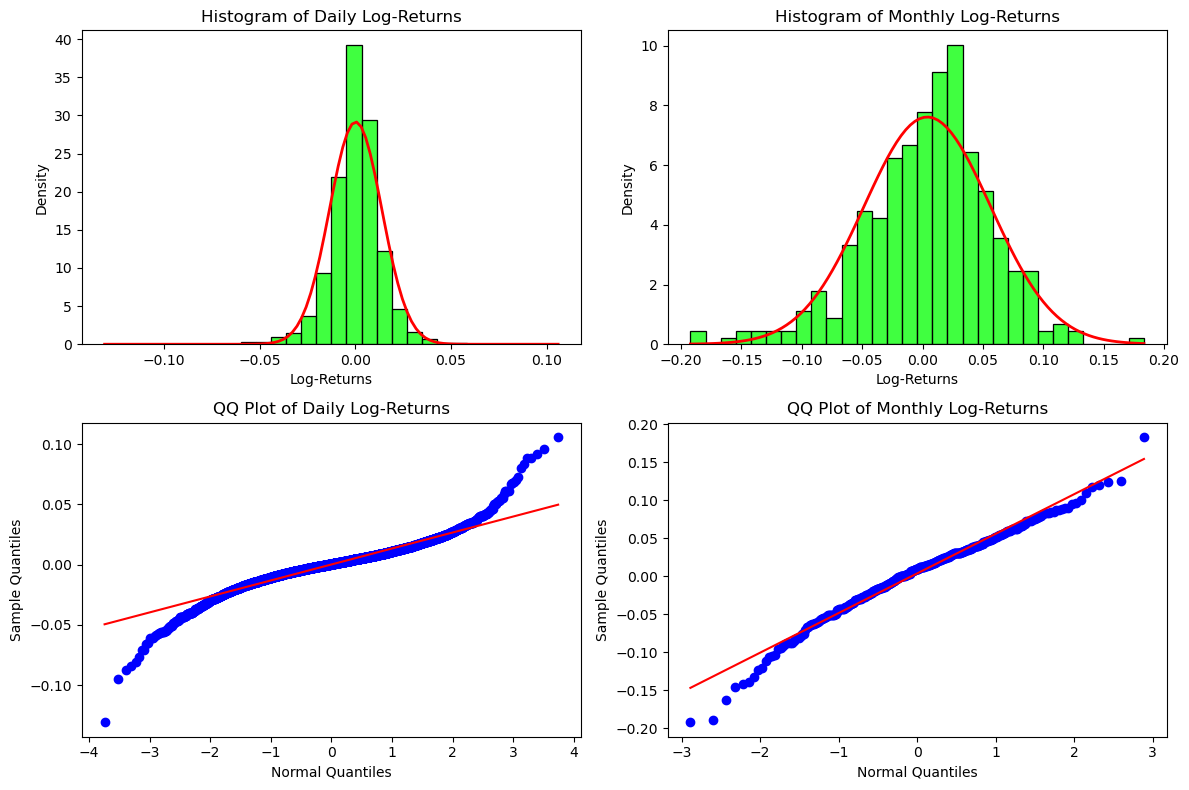

In [13]:
# Create the figure with four subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot histogram of daily log-returns
sns.histplot(log_returns_daily, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 0], stat='density')
axs[0, 0].plot(np.linspace(log_returns_daily.min(), log_returns_daily.max(), 100),
               stats.norm.pdf(np.linspace(log_returns_daily.min(), log_returns_daily.max(), 100),
                              log_returns_daily.mean(), log_returns_daily.std()), color='red', linewidth=2)
axs[0, 0].set_title('Histogram of Daily Log-Returns')
axs[0, 0].set_xlabel('Log-Returns')
axs[0, 0].set_ylabel('Density')

# Plot histogram of monthly log-returns
sns.histplot(log_returns_monthly, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 1], stat='density')
axs[0, 1].plot(np.linspace(log_returns_monthly.min(), log_returns_monthly.max(), 100),
               stats.norm.pdf(np.linspace(log_returns_monthly.min(), log_returns_monthly.max(), 100),
                              log_returns_monthly.mean(), log_returns_monthly.std()), color='red', linewidth=2)
axs[0, 1].set_title('Histogram of Monthly Log-Returns')
axs[0, 1].set_xlabel('Log-Returns')
axs[0, 1].set_ylabel('Density')

# QQ plot of daily log-returns
qqplot_axes = stats.probplot(log_returns_daily, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('QQ Plot of Daily Log-Returns')
axs[1, 0].set_xlabel('Normal Quantiles')
axs[1, 0].set_ylabel('Sample Quantiles')

# QQ plot of monthly log-returns
qqplot_axes = stats.probplot(log_returns_monthly, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('QQ Plot of Monthly Log-Returns')
axs[1, 1].set_xlabel('Normal Quantiles')
axs[1, 1].set_ylabel('Sample Quantiles')

# Adjust spacing between plots
plt.tight_layout()

# Save the plot in png format
plt.savefig('hist_qqplot_CAC40.png', format='png', bbox_inches='tight')

plt.show()

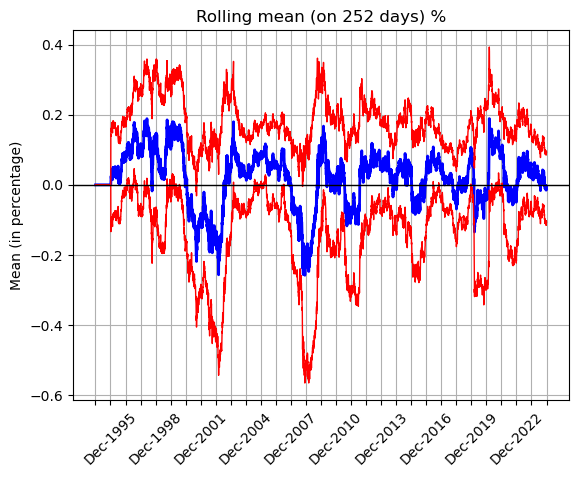

In [14]:
# set the rolling window equal to 252 days
window_length = 252
T = log_returns_daily.shape[0]

# Create an empty matrix to store data
roll_mom_manual = np.zeros((T, 5))

# Run a for loop to fill the matrix with moments
for i in range(window_length, T):
    est_window = np.arange(i - window_length + 1, i + 1)
    y = log_returns_daily.iloc[est_window]
    
    # compute the moments for each 
    roll_mom_manual[i, 0] = np.mean(y)
    roll_mom_manual[i, 1] = np.std(y, ddof=1)
    roll_mom_manual[i, 2] = skew(y)
    roll_mom_manual[i, 3] = kurtosis(y)
    roll_mom_manual[i, 4] = np.mean((y - np.mean(y))**4)

# Plot results of manually computed rolling mean
mean_plot_man = roll_mom_manual[:, 0]
mean_plot_man_ub = mean_plot_man + 1.96 * roll_mom_manual[:, 1] / np.sqrt(window_length)
mean_plot_man_lb = mean_plot_man - 1.96 * roll_mom_manual[:, 1] / np.sqrt(window_length)

data2plot_na = np.column_stack((mean_plot_man, mean_plot_man_lb, mean_plot_man_ub))

data_index = log_returns_daily.index

data2plot_na = pd.DataFrame({'Mean': mean_plot_man, 'LowerBound': mean_plot_man_lb, 'UpperBound': mean_plot_man_ub},
                               index=data_index)

# Select only rows without missing values
data2plot = data2plot_na.dropna()
# retrieve the data index
data2plot

# Customizing x-axis labels for December 31 of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
# Show 1 tick every 3 years
formatted_labels = [f'Dec-{date.year}' if date.year % 3 == 0 else '' for date in date_labels]
# Add labels and rotate them 
plt.xticks(date_labels, formatted_labels, rotation=45)


# Plot the data
plt.plot(data2plot.index, data2plot["Mean"] * 100, color='blue', linestyle='-', linewidth=2)
plt.plot(data2plot.index, data2plot["LowerBound"] * 100, color='red', linestyle='-', linewidth=1)
plt.plot(data2plot.index, data2plot["UpperBound"] * 100, color='red', linestyle='-', linewidth=1)
plt.grid(True)
plt.xlabel('')
plt.ylabel('Mean (in percentage)')
plt.title('Rolling mean (on 252 days) %')
plt.axhline(0, linestyle='-', color='black', linewidth=1)  # Add a zero line

plt.show()

/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/452271008.py:4: RuntimeWarning: divide by zero encountered in divide
  sd_plot_ub = roll_mom_manual[:,1]+1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)
/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/452271008.py:4: RuntimeWarning: invalid value encountered in multiply
  sd_plot_ub = roll_mom_manual[:,1]+1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)
/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/452271008.py:5: RuntimeWarning: divide by zero encountered in divide
  sd_plot_lb = roll_mom_manual[:,1]-1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)
/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/452271008.py:5: RuntimeWarning: invalid value encountered in multiply
  sd_plot_lb = roll_mom_manual[:,1]-1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)


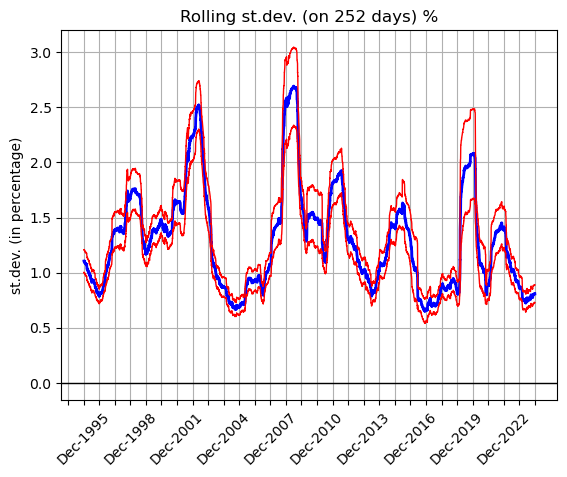

In [15]:
# extract the Std Dev from roll_mom_manual
sd_plot = roll_mom_manual[:,1]
mu4 = roll_mom_manual[:,4]
sd_plot_ub = roll_mom_manual[:,1]+1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)
sd_plot_lb = roll_mom_manual[:,1]-1.96*(1/(2*sd_plot)*np.sqrt(mu4-sd_plot**4))/np.sqrt(window_length)

data2plot_na = np.column_stack((sd_plot, sd_plot_lb, sd_plot_ub))

data_index = log_returns_daily.index

data2plot_na = pd.DataFrame({'StD': sd_plot, 'LowerBound': sd_plot_lb, 'UpperBound': sd_plot_ub},
                               index=data_index)

# Select only rows without missing values
data2plot = data2plot_na.dropna()
# retrieve the data index
data2plot

# Customizing x-axis labels for December 31 of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
# Show 1 tick every 3 years
formatted_labels = [f'Dec-{date.year}' if date.year % 3 == 0 else '' for date in date_labels]
# Add labels and rotate them 
plt.xticks(date_labels, formatted_labels, rotation=45)

# Plot the data
plt.plot(data2plot.index, data2plot["StD"] * 100, color='blue', linestyle='-', linewidth=2)
plt.plot(data2plot.index, data2plot["LowerBound"] * 100, color='red', linestyle='-', linewidth=1)
plt.plot(data2plot.index, data2plot["UpperBound"] * 100, color='red', linestyle='-', linewidth=1)
plt.xlabel('')
plt.grid(True)
plt.ylabel('st.dev. (in percentage)')
plt.title('Rolling st.dev. (on 252 days) %')
plt.axhline(0, linestyle='-', color='black', linewidth=1)  # Add a zero line

plt.show()

# Stylized Fact 3 : Returns are Asymmetric (Negative Skewness)
# Stylized Fact 4 : Returns have heavy tails (Large Excess kurtosis)

# use the image on the top left corner for Stylized Fact 3, use the image on bottom left for fact 4 

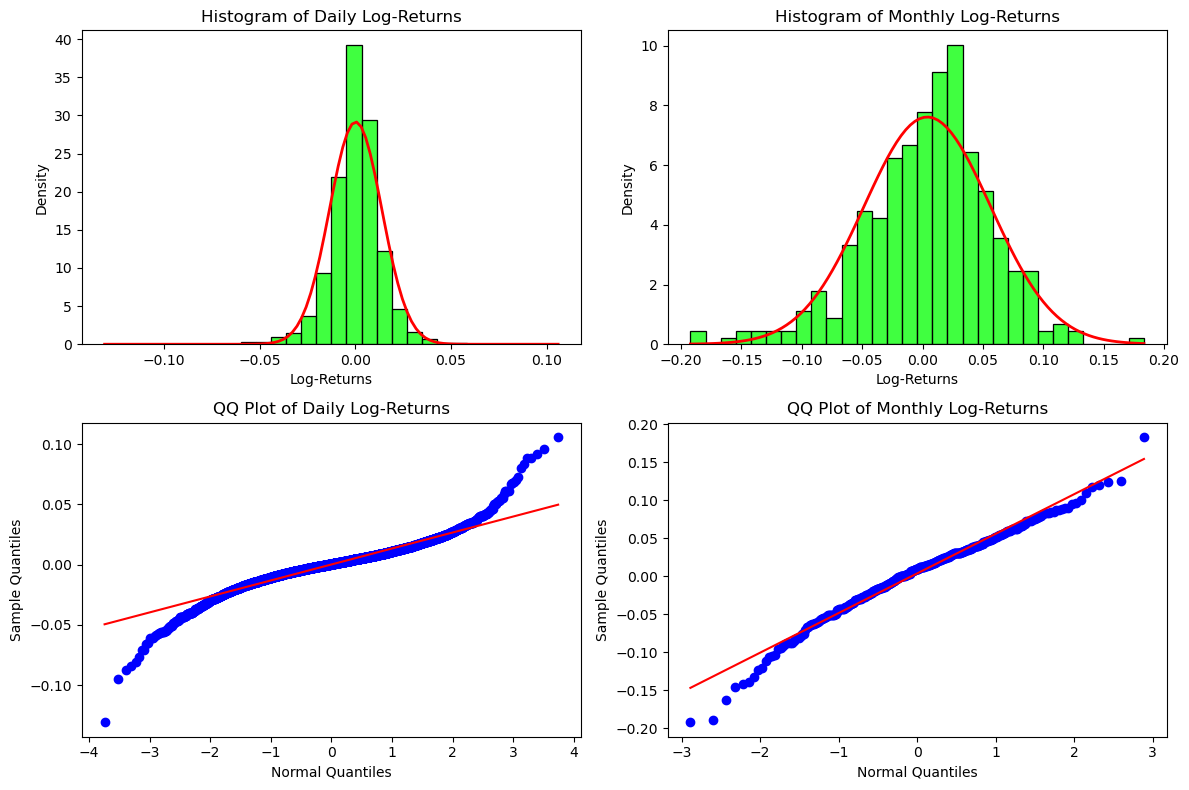

In [16]:
# Create the figure with four subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot histogram of daily log-returns
sns.histplot(log_returns_daily, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 0], stat='density')
axs[0, 0].plot(np.linspace(log_returns_daily.min(), log_returns_daily.max(), 100),
               stats.norm.pdf(np.linspace(log_returns_daily.min(), log_returns_daily.max(), 100),
                              log_returns_daily.mean(), log_returns_daily.std()), color='red', linewidth=2)
axs[0, 0].set_title('Histogram of Daily Log-Returns')
axs[0, 0].set_xlabel('Log-Returns')
axs[0, 0].set_ylabel('Density')

# Plot histogram of monthly log-returns
sns.histplot(log_returns_monthly, bins=30, color='lime', edgecolor='black', kde_kws={'color': 'red'}, ax=axs[0, 1], stat='density')
axs[0, 1].plot(np.linspace(log_returns_monthly.min(), log_returns_monthly.max(), 100),
               stats.norm.pdf(np.linspace(log_returns_monthly.min(), log_returns_monthly.max(), 100),
                              log_returns_monthly.mean(), log_returns_monthly.std()), color='red', linewidth=2)
axs[0, 1].set_title('Histogram of Monthly Log-Returns')
axs[0, 1].set_xlabel('Log-Returns')
axs[0, 1].set_ylabel('Density')

# QQ plot of daily log-returns
qqplot_axes = stats.probplot(log_returns_daily, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('QQ Plot of Daily Log-Returns')
axs[1, 0].set_xlabel('Normal Quantiles')
axs[1, 0].set_ylabel('Sample Quantiles')

# QQ plot of monthly log-returns
qqplot_axes = stats.probplot(log_returns_monthly, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('QQ Plot of Monthly Log-Returns')
axs[1, 1].set_xlabel('Normal Quantiles')
axs[1, 1].set_ylabel('Sample Quantiles')

# Adjust spacing between plots
plt.tight_layout()

# Save the plot in png format
plt.savefig('hist_qqplot_CAC40.png', format='png', bbox_inches='tight')

plt.show()

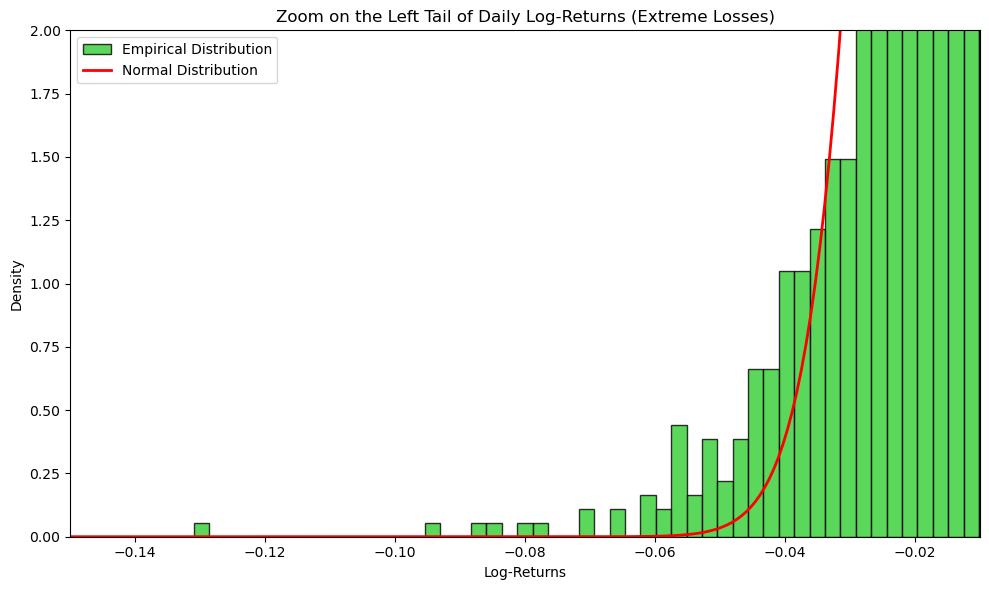

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Single subplot for clarity

# Histogram of daily log returns
ax.hist(log_returns_daily, bins=100, density=True, alpha=0.8,
           color='limegreen', edgecolor='black', label='Empirical Distribution')

# Overlay Normal PDF
x_vals = np.linspace(log_returns_daily.min()*1.2, log_returns_daily.max()*1.2, 400)
ax.plot(x_vals, stats.norm.pdf(x_vals, log_returns_daily.mean(), log_returns_daily.std(ddof=0)),
           color='red', lw=2, label='Normal Distribution')

# =====================================================================
# ---- ZOOM on the left tail (losses) ----
# Setting the X-axis to cover significant negative values (e.g., -0.15 to -0.01)
ax.set_xlim(-0.15, -0.01)

# Adjusting the Y-axis to clearly show the bars in this region.
ax.set_ylim(0, 2)
# =====================================================================

#ax.axvline(log_returns_daily.mean(), color='black', lw=1, linestyle='--', label='Empirical Mean')
ax.legend()

# --- Titles ---
ax.set_title('Zoom on the Left Tail of Daily Log-Returns (Extreme Losses)')
ax.set_xlabel('Log-Returns')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

# Stylized Fact 5: Aggregational Gaussianity

# Stylized Fact 6 : Returns are not autocorrelated

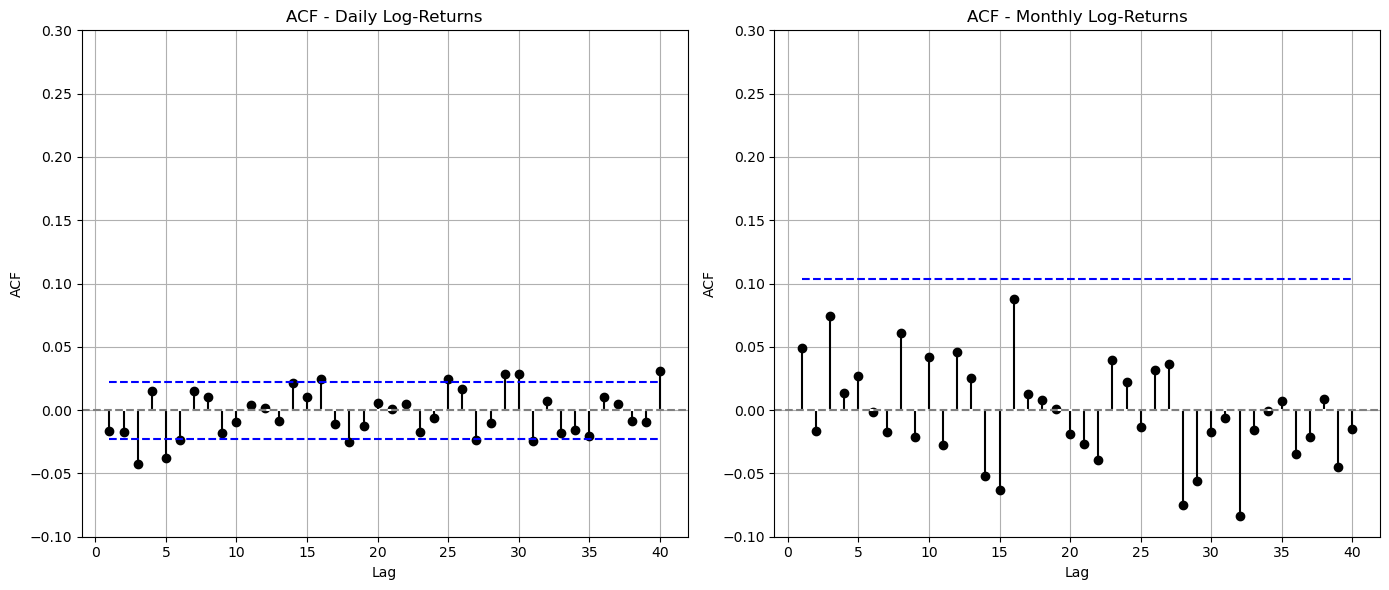

In [18]:
# Paramètres
lags = 40

# --- Daily ---
acf_daily = acf(log_returns_daily, nlags=lags)
confint_daily = 1.96 / np.sqrt(len(log_returns_daily))
confint_daily_upper = np.full(lags, confint_daily)
confint_daily_lower = -np.full(lags, confint_daily)

# --- Monthly ---
acf_monthly = acf(log_returns_monthly, nlags=lags)
confint_monthly = 1.96 / np.sqrt(len(log_returns_monthly))
confint_monthly_upper = np.full(lags, confint_monthly)
confint_monthly_lower = -np.full(lags, confint_monthly)

# Créer la figure avec 1 ligne et 2 colonnes
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# ACF Daily
axs[0].stem(np.arange(1, lags + 1), acf_daily[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].plot(np.arange(1, lags + 1), confint_daily_upper, color='blue', linestyle='dashed')
axs[0].plot(np.arange(1, lags + 1), confint_daily_lower, color='blue', linestyle='dashed')
axs[0].set_ylim(-0.1, 0.3)
axs[0].set_title('ACF - Daily Log-Returns')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('ACF')
axs[0].grid(True)

# ACF Monthly
axs[1].stem(np.arange(1, lags + 1), acf_monthly[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].plot(np.arange(1, lags + 1), confint_monthly_upper, color='blue', linestyle='dashed')
axs[1].plot(np.arange(1, lags + 1), confint_monthly_lower, color='blue', linestyle='dashed')
axs[1].set_ylim(-0.1, 0.3)
axs[1].set_title('ACF - Monthly Log-Returns')
axs[1].set_xlabel('Lag')
axs[1].set_ylabel('ACF')
axs[1].grid(True)

# Ajuster les espacements
plt.tight_layout()
plt.show()


In [19]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import chi2

# ---- input series ----
r = pd.Series(log_returns_daily).dropna()
T = len(r)
K = 15  # number of lags to display

# ---- ACF and "diameter" (95% bands under white-noise) ----
rho = acf(r, nlags=K, fft=True)[1:]                 # skip lag 0 -> shape (K,)
acf_diam = 1.96 / np.sqrt(T)                        # same for all lags
acf_t = rho * np.sqrt(T)                            # approx t-test: rho_k / (1/sqrt(T))

# ---- Ljung-Box & Box-Pierce ----
lb = acorr_ljungbox(r, lags=np.arange(1, K+1), boxpierce=True, return_df=True)

# ---- Chi-square 0.95 critical values ----
chi_crit = chi2.ppf(0.95, df=np.arange(1, K+1))

# ---- assemble table ----
table = pd.DataFrame({
    "lag (k)":            np.arange(1, K+1),
    "ACF (ρ_k)":          rho,
    "ACF diam.":          np.full(K, acf_diam),
    "ACF t-test":         acf_t,
    "Box–Pierce stat":    lb["bp_stat"].values,
    "BP pval":            lb["bp_pvalue"].values,
    "Ljung–Box stat":     lb["lb_stat"].values,
    "LB pval":            lb["lb_pvalue"].values,
    "χ²_{k,0.95}":        chi_crit
})

# ---- pretty formatting (like your slide) ----
def fmt(x): return f"{x:.3f}"
styled = (table.set_index("lag (k)")
               .style.format(fmt)
               .set_table_styles([
                   {"selector":"table","props":"border-collapse:collapse; border:1px solid black;"},
                   {"selector":"thead th","props":"border-bottom:2px solid black; padding:6px 10px; font-weight:bold;"},
                   {"selector":"tbody th","props":"padding:6px 10px; font-weight:bold;"},
                   {"selector":"tbody td","props":"padding:6px 14px;"},
               ])
               .set_caption("Tests for autocorrelations (daily log-returns)")
          )

styled  # in a notebook this renders the nice table

,ACF (ρ_k),ACF diam.,ACF t-test,Box–Pierce stat,BP pval,Ljung–Box stat,LB pval,"χ²_{k,0.95}"
lag (k),,,,,,,,
1,-0.017,0.022,-1.469,2.157,0.142,2.158,0.142,3.841
2,-0.017,0.022,-1.529,4.496,0.106,4.498,0.106,5.991
3,-0.043,0.022,-3.728,18.393,0.000,18.405,0.000,7.815
4,0.015,0.022,1.338,20.184,0.000,20.196,0.000,9.488
5,-0.038,0.022,-3.297,31.057,0.000,31.079,0.000,11.070
6,-0.023,0.022,-2.036,35.201,0.000,35.228,0.000,12.592
7,0.015,0.022,1.303,36.899,0.000,36.928,0.000,14.067
8,0.010,0.022,0.899,37.707,0.000,37.737,0.000,15.507
9,-0.018,0.022,-1.558,40.134,0.000,40.168,0.000,16.919


# Stylized fact 7: Volatility clustering and long range dependence of squared returns

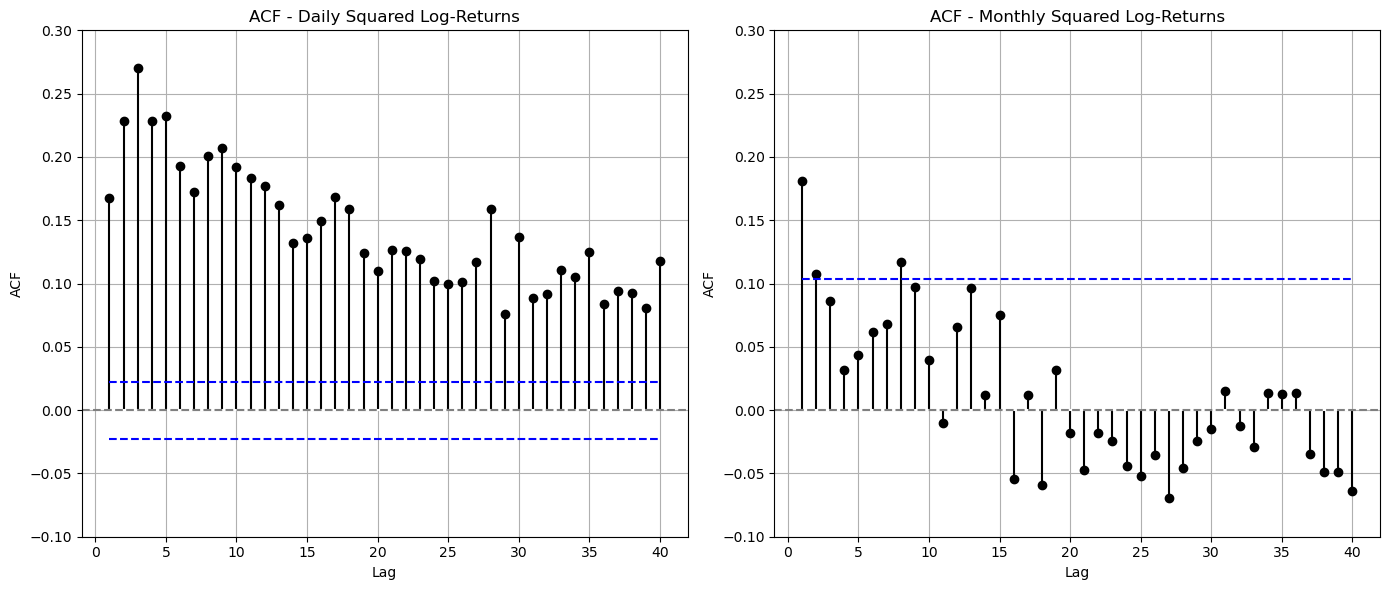

In [20]:
# Parameters
lags = 40

# --- Daily squared log-returns ---
acf_daily_sq = acf(log_returns_daily**2, nlags=lags)
confint_daily = 1.96 / np.sqrt(len(log_returns_daily))
confint_daily_upper = np.full(lags, confint_daily)
confint_daily_lower = -np.full(lags, confint_daily)

# --- Monthly squared log-returns ---
acf_monthly_sq = acf(log_returns_monthly**2, nlags=lags)
confint_monthly = 1.96 / np.sqrt(len(log_returns_monthly))
confint_monthly_upper = np.full(lags, confint_monthly)
confint_monthly_lower = -np.full(lags, confint_monthly)

# Create the figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- ACF of daily squared log-returns ---
axs[0].stem(np.arange(1, lags + 1), acf_daily_sq[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[0].axhline(y=0, color='gray', linestyle='--')
axs[0].plot(np.arange(1, lags + 1), confint_daily_upper, color='blue', linestyle='dashed')
axs[0].plot(np.arange(1, lags + 1), confint_daily_lower, color='blue', linestyle='dashed')
axs[0].set_ylim(-0.1, 0.3)
axs[0].set_title('ACF - Daily Squared Log-Returns')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('ACF')
axs[0].grid(True)

# --- ACF of monthly squared log-returns ---
axs[1].stem(np.arange(1, lags + 1), acf_monthly_sq[1:], linefmt='k-', markerfmt='ko', basefmt='w-')
axs[1].axhline(y=0, color='gray', linestyle='--')
axs[1].plot(np.arange(1, lags + 1), confint_monthly_upper, color='blue', linestyle='dashed')
axs[1].plot(np.arange(1, lags + 1), confint_monthly_lower, color='blue', linestyle='dashed')
axs[1].set_ylim(-0.1, 0.3)
axs[1].set_title('ACF - Monthly Squared Log-Returns')
axs[1].set_xlabel('Lag')
axs[1].set_ylabel('ACF')
axs[1].grid(True)

# Adjust spacing between subplots
plt.tight_layout()

# Save the plot in PNG format
plt.savefig('ACF_squared_log_returns_CAC40.png', format='png', bbox_inches='tight')

# Display the plots
plt.show()

# Stylized fact 8: Leverage Effect

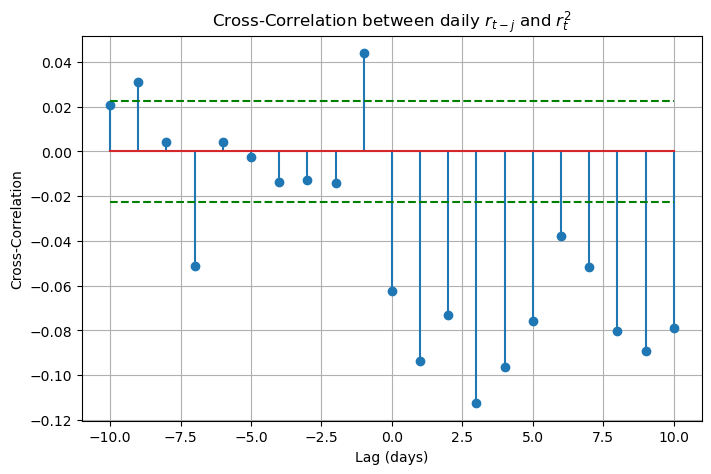

In [21]:

# compute the squared returns
rt_d2 = log_returns_daily**2
# define a function
def ccf(x, y, lag_max = 100):
    # compute correlation
    result = ss.correlate(y - np.mean(y), x - np.mean(x), method='direct') / (np.std(y) * np.std(x) * len(y))
    # define the length
    length = (len(result) - 1) // 2
    lo = length - lag_max
    hi = length + (lag_max + 1)

    return result[lo:hi]

# choose the max lag and execute the function
lag_max = 10
cross_corr = ccf(log_returns_daily,rt_d2,lag_max=lag_max)

# plot results
lags = np.arange(-lag_max, lag_max + 1)

# ACF dei log-returns mensili con bande di confidenza
confint_daily = 1.96 / np.sqrt(len(log_returns_daily))
confint_daily_upper = np.full(len(lags), confint_daily)
confint_daily_lower = -np.full(len(lags), confint_daily)

plt.figure(figsize=(8, 5))
plt.stem(lags, cross_corr)
plt.plot(lags, confint_daily_upper, color='green', linestyle='dashed')
plt.plot(lags, confint_daily_lower, color='green', linestyle='dashed')
plt.xlabel('Lag (days)')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation between daily $r_{t-j}$ and $r_t^2$')
plt.grid(True)
plt.savefig('ccf_updated20250904.png')
plt.show()

/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/2023526932.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  VIX = yf.download("^VIX", start="1994-12-31", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


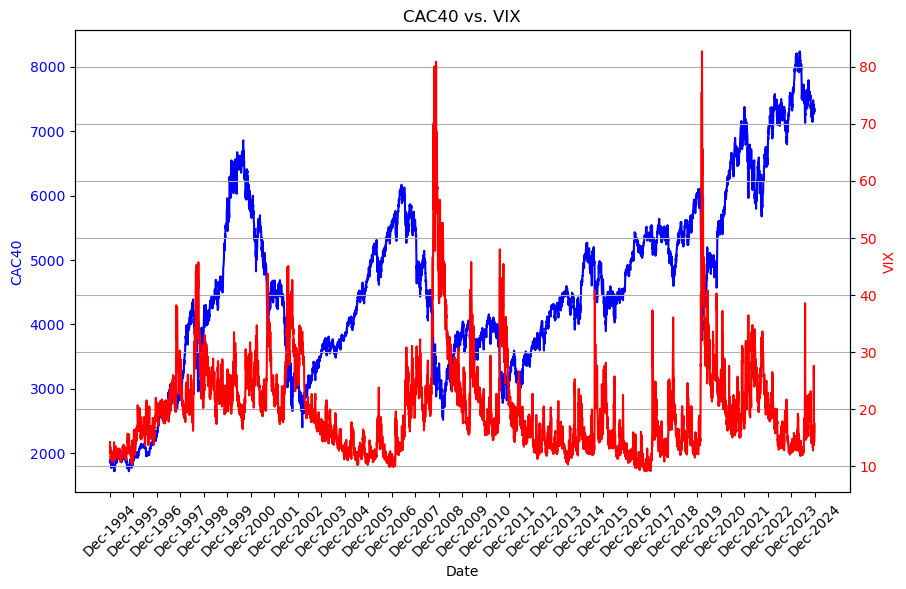

In [22]:
# get S&P and VIX data
VIX = yf.download("^VIX", start="1994-12-31", end="2024-12-31")

# extract the adjusted closing prices
Pt_d = CAC40["Close"]
VIX_d = VIX["Close"]

# rename the columns
VIX_d = VIX_d.rename(columns={VIX_d.columns[0]: "VIX.d"})
Pt_d = Pt_d.rename(columns={Pt_d.columns[0]: "Pt.d"})

# mutate the Index into a DatetimeIndex
VIX_d.index = pd.to_datetime(VIX_d.index)  

# merge the two datasets and rename columns
merged_df = pd.merge(Pt_d, VIX_d, on='Date', how='outer') # outer: only commond indexes (dates)
merged_df.head()

# Compute changes in pt and VIX compared to previous period (NaN are kept)
diff_df = merged_df.diff()
diff_df.head()

# remove from the price dataframe
merged_df = merged_df.dropna()
# and from the second one
diff_df = diff_df.dropna()

# define the figure parameters
fig, ax1 = plt.subplots(figsize=(10, 6))

# Customizing x-axis labels for December of each year
date_labels = pd.date_range(start='1994-12-31', end='2024-12-31', freq='YE-DEC')
formatted_labels = [f'Dec-{date.year}' for date in date_labels]
# Add label and rotate them
plt.xticks(date_labels, formatted_labels, rotation=45)

# work on the first y-axis: S&P
ax1.plot(merged_df.index, merged_df['Pt.d'], label='CAC40 Prices', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('CAC40', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# work on the second y-axis: VIX
ax2 = ax1.twinx()
ax2.plot(merged_df.index, merged_df['VIX.d'], label='VIX', color='red')
ax2.set_ylabel('VIX', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add labels and title to the plot
plt.title('CAC40 vs. VIX')
plt.grid(True)

# Save the plot as a PNG file
plt.savefig('CAC40_VIX_1994_2024.png', format='png', bbox_inches='tight')

# Show the plot
plt.show()

# QUESTION 2

In [23]:
import pandas as pd
import yfinance as yf

# DOWNLOAD DATA
date_start = "1994-12-31"
date_end = "2024-12-31"

# CAC 40
CAC40 = yf.download("^FCHI", start=date_start, end=date_end,auto_adjust=True)

CAC40 = CAC40['Close'].resample('ME').last()

def f(x):
    return pd.to_datetime(x, format="%Y%m")

# NOTE: RISK FREE RATE: 1m-Tbill form Fama and French
FF_factors_m = pd.read_csv("FF_Research_Data_Factors_monthly.csv", sep=",", skiprows=3, header=0, parse_dates=[0], date_format=f, index_col=0)


[*********************100%***********************]  1 of 1 completed


In [24]:
CAC40_ad = CAC40.iloc[:, 0].to_frame()  # montlhy adj. prices, the 1st column is adjusted prices
rf_m = FF_factors_m.iloc[:, 3].to_frame()  # monthly risk-free rate (daily 1 month Tbill), 4th column

ffm_m = FF_factors_m.iloc[:, 0:3]  # 3 Fama-French factors (monthly frequency)
# NOTE: 1st column of FF dataset is CRSP VW-rf

# rename the index of ffm_d & ffm_m 
rf_m = rf_m.rename_axis("Date")
ffm_m = ffm_m.rename_axis("Date")
ffm_m.head()

,Mkt-RF,SMB,HML
Date,,,
192607,2.96,-2.30,-2.87
192608,2.64,-1.40,4.19
192609,0.36,-1.32,0.01
192610,-3.24,0.04,0.51
192611,2.53,-0.20,-0.35


In [25]:
# Compute: monthly returns 

prices = CAC40_ad.rename(columns={'Close': 'CAC40'})
prices.head()

,^FCHI
Date,
1995-01-31,1797.900024
1995-02-28,1776.900024
1995-03-31,1859.500000
1995-04-30,1918.500000
1995-05-31,1948.000000


In [26]:
# compute the log-returns *100 of the CAC40
ret_m_eq = np.log(prices / prices.shift(1)) * 100

# remove the first line which contains a NaN
ret_m_eq = ret_m_eq[1:]
ret_m_eq.head()

,^FCHI
Date,
1995-02-28,-1.174904
1995-03-31,4.543735
1995-04-30,3.123600
1995-05-31,1.525957
1995-06-30,-4.687206


In [27]:
# --- RELOAD AND CONVERT CORRECTLY ---

# Reload WITHOUT parse_dates (because the format is YYYYMM as a number)
FF_factors_m = pd.read_csv("FF_Research_Data_Factors_monthly.csv", sep=",", skiprows=3, header=0, index_col=0)

# Convert YYYYMM index to dates
FF_factors_m.index = pd.to_datetime(FF_factors_m.index, format='%Y%m')

# Recreate ffm_m and rf_m
rf_m = FF_factors_m.iloc[:, 3].to_frame()  # monthly risk-free rate
ffm_m = FF_factors_m.iloc[:, 0:3]  # 3 Fama-French factors

# Rename the indexes
rf_m = rf_m.rename_axis("Date")
ffm_m = ffm_m.rename_axis("Date")

# --- NORMALIZE TO FIRST DAY OF MONTH ---
ret_m_eq.index = pd.to_datetime(ret_m_eq.index).to_period('M').to_timestamp()
ffm_m.index = ffm_m.index.to_period('M').to_timestamp()
rf_m.index = rf_m.index.to_period('M').to_timestamp()

# --- JOIN ---
ret_m_all = ffm_m.join(ret_m_eq, how='inner').join(rf_m, how='inner')

ret_m_all.head()

,Mkt-RF,SMB,HML,^FCHI,RF
Date,,,,,
1995-02-01,3.63,-0.67,1.08,-1.174904,0.40
1995-03-01,2.19,-0.70,-1.07,4.543735,0.46
1995-04-01,2.11,-0.62,2.26,3.123600,0.44
1995-05-01,2.90,-2.20,1.69,1.525957,0.54
1995-06-01,2.72,2.93,-2.27,-4.687206,0.47


In [28]:
# compute matrix of DAILY returns
ret_m_all["Mkt-RF"] = ret_m_all["Mkt-RF"] + ret_m_all["RF"];
ret_m_all = ret_m_all.rename(columns={"Mkt-RF": "CRSP_VW"})
ret_m_all

,CRSP_VW,SMB,HML,^FCHI,RF
Date,,,,,
1995-02-01,4.03,-0.67,1.08,-1.174904,0.40
1995-03-01,2.65,-0.70,-1.07,4.543735,0.46
1995-04-01,2.55,-0.62,2.26,3.123600,0.44
1995-05-01,3.44,-2.20,1.69,1.525957,0.54
1995-06-01,3.19,2.93,-2.27,-4.687206,0.47
...,...,...,...,...,...
2019-02-01,3.58,2.02,-2.84,4.844170,0.18
2019-03-01,1.29,-3.15,-4.07,2.077298,0.19
2019-04-01,4.17,-1.70,1.98,4.314131,0.21


In [29]:
# computes excess returns 
z_m_all = ret_m_all.drop(["RF"], axis=1)

col_ret = [0, 3]

for col in col_ret:
    z_m_all.iloc[:, col] = ret_m_all.iloc[:, col] - ret_m_all.iloc[:, 4]
    
z_m_all

,CRSP_VW,SMB,HML,^FCHI
Date,,,,
1995-02-01,3.63,-0.67,1.08,-1.574904
1995-03-01,2.19,-0.70,-1.07,4.083735
1995-04-01,2.11,-0.62,2.26,2.683600
1995-05-01,2.90,-2.20,1.69,0.985957
1995-06-01,2.72,2.93,-2.27,-5.157206
...,...,...,...,...
2019-02-01,3.40,2.02,-2.84,4.664170
2019-03-01,1.10,-3.15,-4.07,1.887298
2019-04-01,3.96,-1.70,1.98,4.104131


In [30]:
ret_m = ret_m_all
z_m = z_m_all

# Dataframe
ret_m_df = pd.DataFrame({'date': ret_m.index, 'CRSP_VW': ret_m['CRSP_VW'], 'SMB': ret_m['SMB'],
                         'HML': ret_m['HML'], 'CAC40': ret_m['^FCHI'], 'rf': ret_m['RF']})

z_m_df = pd.DataFrame({'date': ret_m.index, 'CRSP_VW': ret_m['CRSP_VW'], 'SMB': ret_m['SMB'],
                         'HML': ret_m['HML'], 'CAC40': ret_m['^FCHI'], 'rf': ret_m['RF']})
ret_m_df.head()

,date,CRSP_VW,SMB,HML,CAC40,rf
Date,,,,,,
1995-02-01,1995-02-01,4.03,-0.67,1.08,-1.174904,0.40
1995-03-01,1995-03-01,2.65,-0.70,-1.07,4.543735,0.46
1995-04-01,1995-04-01,2.55,-0.62,2.26,3.123600,0.44
1995-05-01,1995-05-01,3.44,-2.20,1.69,1.525957,0.54
1995-06-01,1995-06-01,3.19,2.93,-2.27,-4.687206,0.47


# END OF DATA IMPORT AND MANIPULATIONS

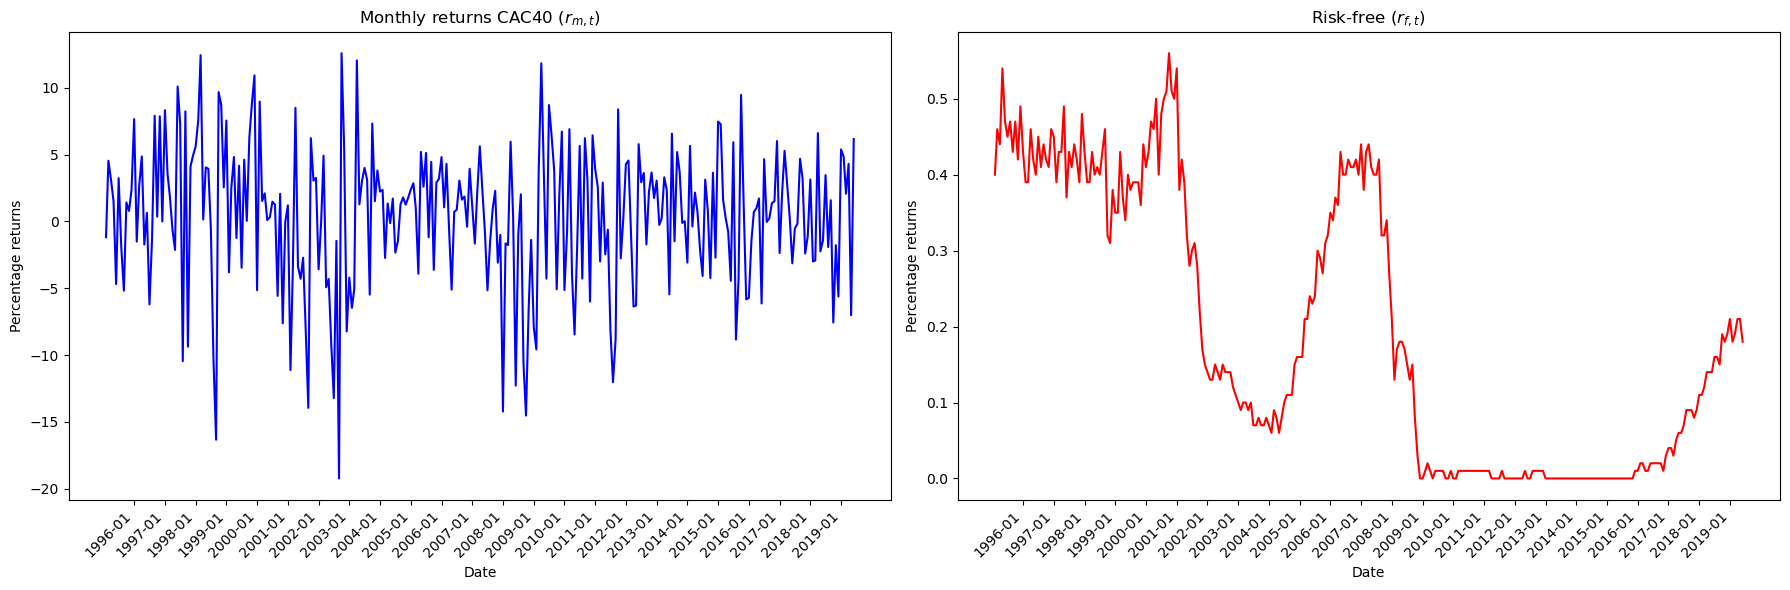

In [31]:
import matplotlib.pyplot as plt

d2plot = ret_m_df
seq_sel = list(range(11, len(d2plot), 12))
date_lab = d2plot['date'].iloc[seq_sel]

# Define a 1x2 grid for the 2 subplots
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# CAC40 (Subplot 1)
axs[0].plot(d2plot['date'], d2plot['CAC40'], linestyle='-', marker='', color='blue')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Percentage returns')
axs[0].set_title('Monthly returns CAC40 ($r_{m,t}$)')
axs[0].set_xticks(date_lab)
# Format dates to show only YYYY-MM
axs[0].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=45, ha="right")

# r-f (Subplot 2)
axs[1].plot(d2plot['date'], d2plot['rf'], linestyle='-', marker='', color='red')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Percentage returns')
axs[1].set_title('Risk-free ($r_{f,t}$)')
axs[1].set_xticks(date_lab)
# Format dates to show only YYYY-MM
axs[1].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=45, ha="right")

plt.tight_layout()
plt.show()

# CAPM REGRESSION

In [32]:
# CAC40 vs. CRSP_VW
y = z_m_df.iloc[:, 4]  
x1 = z_m_df.iloc[:, 1]
### Linear Regression
X1 = sm.add_constant(x1)  
reg1 = sm.OLS(y, X1).fit()
reg1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  CAC40   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     407.4
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           2.92e-57
Time:                        20:28:13   Log-Likelihood:                -773.46
No. Observations:                 293   AIC:                             1551.
Df Residuals:                     291   BIC:                             1558.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4383      0.203     -2.160      0.032      -0.838      -0.039
CRSP_VW        0.9189      0.046     20.184      0.000       0.829       1.008
==============================================================================
Omnibus:                       76.314   Durbin-Watson:                   2.244
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              408.222
Skew:                          -0.937   Prob(JB):                     2.27e-89
Kurtosis:                       8.471   Cond. No.                         4.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
from statsmodels.iolib.summary2 import summary_col
summary = summary_col([reg1], stars=True, float_format="%.4f", model_names=["CAC40 CAPM"])
summary 

,CAC40 CAPM
const,-0.4383**
,(0.2029)
CRSP_VW,0.9189***
,(0.0455)
R-squared,0.5833
R-squared Adj.,0.5819


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


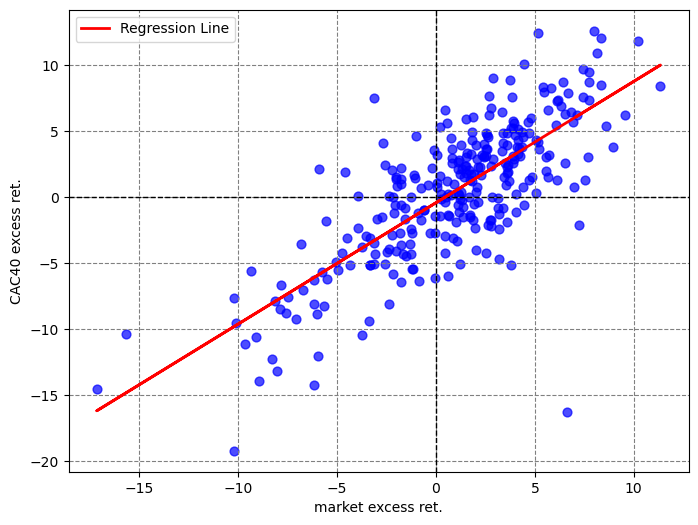

In [34]:
# represent the predicted values through an histogram
plt.figure(figsize=(8, 6))
plt.scatter(x1, y, color="blue", s=40, alpha=0.7)
plt.xlabel("market excess ret.")
plt.ylabel("CAC40 excess ret.")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.grid(linestyle="--", color="grey")

# Compute the predicted values
y_pred = reg1.predict(X1)

# Draw the regression line in red
plt.plot(x1, y_pred, color="red", linewidth=2, label="Regression Line")

plt.legend()
plt.savefig("CRSP_VW_IBM_scatter1418m_regline.eps")

plt.show()


# 3 Factors model of Fama and French

In [35]:
# CAC40 monthly excess ret.
y = z_m_df.iloc[:, 4]  
T = len(y)

# Extract data columns
CAC40 = z_m_df.iloc[:, 4]  # IBM
MKT = z_m_df.iloc[:, 1]  # CRSP VW
SMB = z_m_df.iloc[:, 2]  # SMB
HML = z_m_df.iloc[:, 3]  # HML

X2 = np.column_stack((np.ones(T), MKT, SMB, HML)) 

# Perform linear regression
reg2 = sm.OLS(y, X2).fit()  # Include constant term

summary2 = summary_col([reg2], stars=True, float_format="%.4f", model_names=["CAC40"])
summary2

,CAC40
const,-0.4491**
,(0.2035)
x1,0.9337***
,(0.0470)
x2,-0.0607
,(0.0638)
x3,0.0427
,(0.0677)
R-squared,0.5858
R-squared Adj.,0.5815


In [40]:
# ========== CREATE COMPARISON TABLE ==========

# Build the comparison table
comparison_data = {
    'Coefficient': [
        'Alpha (α)',
        'Standard Error (α)',
        'Beta Market (β_Mkt)',
        'Standard Error (β_Mkt)',
        'Beta SMB (β_SMB)',
        'Standard Error (β_SMB)',
        'Beta HML (β_HML)',
        'Standard Error (β_HML)',
        'Adjusted R²'
    ],
    'CAPM (Model 1)': [
        f"{reg1.params[0]:.4f}",
        f"{reg1.bse[0]:.4f}",
        f"{reg1.params[1]:.4f}",
        f"{reg1.bse[1]:.4f}",
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        f"{reg1.rsquared_adj:.3f}"
    ],
    'FF 3-Factor (Model 2)': [
        f"{reg2.params[0]:.4f}",
        f"{reg2.bse[0]:.4f}",
        f"{reg2.params[1]:.4f}",
        f"{reg2.bse[1]:.4f}",
        f"{reg2.params[2]:.4f}",
        f"{reg2.bse[2]:.4f}",
        f"{reg2.params[3]:.4f}",
        f"{reg2.bse[3]:.4f}",
        f"{reg2.rsquared_adj:.3f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the table
#print("\n" + "="*85)
#print(" "*25 + "CAC40 Regression Comparison")
#print("="*85)
#print(comparison_df.to_string(index=False))
#print("="*85 + "\n")

comparison_df

/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/833175065.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{reg1.params[0]:.4f}",
/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/833175065.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{reg1.bse[0]:.4f}",
/var/folders/h7/y_68zhv515l_dhrsqnwxhby00000gn/T/ipykernel_88421/833175065.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{re

,Coefficient,CAPM (Model 1),FF 3-Factor (Model 2)
0,Alpha (α),-0.4383,-0.4491
1,Standard Error (α),0.2029,0.2035
2,Beta Market (β_Mkt),0.9189,0.9337
3,Standard Error (β_Mkt),0.0455,0.0470
4,Beta SMB (β_SMB),N/A,-0.0607
5,Standard Error (β_SMB),N/A,0.0638
6,Beta HML (β_HML),N/A,0.0427
7,Standard Error (β_HML),N/A,0.0677
8,Adjusted R²,0.582,0.581


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


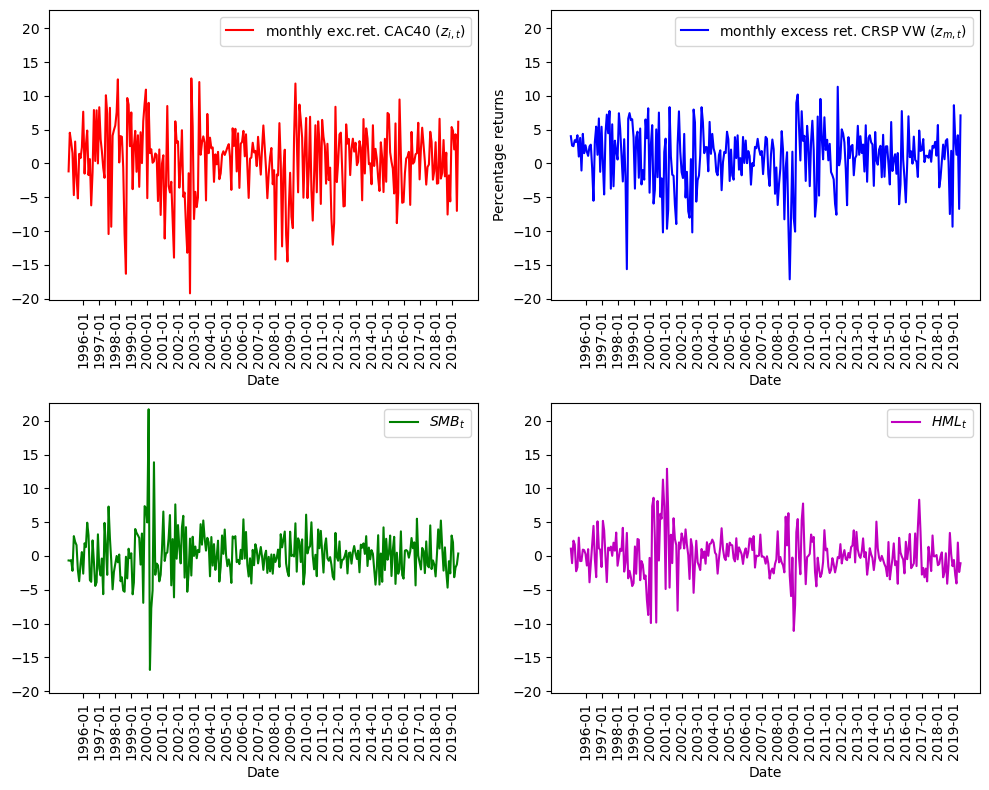

In [37]:
d2plot = z_m_df

# Calculate the range of y values
columns_to_check = d2plot.columns[1:]
# Compute max and min (add +/- 1 to improve the data viz)
min_value = d2plot[columns_to_check].min().min() - 1
max_value = d2plot[columns_to_check].max().max() + 1

# Select date labels for x-axis
seq_sel = list(range(11, len(d2plot), 12))
date_lab = d2plot.iloc[seq_sel, 0]

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot 1: CAC40
axs[0, 0].plot(d2plot.iloc[:, 0], d2plot.iloc[:, 4], 'r-', label='monthly exc.ret. CAC40 ($z_{i,t}$)')
axs[0, 0].set_xlabel('Date')
axs[0, 0].set_ylabel('')
axs[0, 0].set_ylim(min_value, max_value)
axs[0, 0].set_xticks(date_lab)
axs[0, 0].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=90)
axs[0, 0].legend()

# Plot 2: CRSP VW
axs[0, 1].plot(d2plot.iloc[:, 0], d2plot.iloc[:, 1], 'b-', label='monthly excess ret. CRSP VW ($z_{m,t}$)')
axs[0, 1].set_xlabel('Date')
axs[0, 1].set_ylabel('Percentage returns')
axs[0, 1].set_ylim(min_value, max_value)
axs[0, 1].set_xticks(date_lab)
axs[0, 1].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=90)
axs[0, 1].legend()

# Plot 3: SMB
axs[1, 0].plot(d2plot.iloc[:, 0], d2plot.iloc[:, 2], 'g-', label='$SMB_{t}$')
axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('')
axs[1, 0].set_ylim(min_value, max_value)
axs[1, 0].set_xticks(date_lab)
axs[1, 0].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=90)
axs[1, 0].legend()

# Plot 4: HML
axs[1, 1].plot(d2plot.iloc[:, 0], d2plot.iloc[:, 3], 'm-', label='$HML_{t}$')
axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('')
axs[1, 1].set_ylim(min_value, max_value)
axs[1, 1].set_xticks(date_lab)
axs[1, 1].set_xticklabels([d.strftime('%Y-%m') for d in date_lab], rotation=90)
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("CAC40_3FF_ts_1418.eps")
plt.show()
